**Before you start: set up the environment**

---

If you have not set up the virtual environment by `uv` yet, please follow the instructions in the [README](../README.md). 

Otherwise, please synchronize the potential new dependencies by running `uv sync` in the terminal.
Then the virtual environment should be updated and you are ready to start the exercise by selecting the virtual environment for this notebook.

**Exercise 2 - Linear and non-linear regression [10 pt]**

---

This exercise will be about linear and non-linear regression. Given a set of data points your task will be to implement the functions that calculate the function $\theta$ parameters to fit the data. You also need to implement utility functions such as spliting the dataset and computing the evaluation metrics. 

**Note:** Please implement the functions in `mlrcv/regression.py` and `mlrcv/utils.py`—grading is purely based on those implementation. You may use this Jupyter notebook to run and test your code, but you do not need to change the notebook.

In [1]:
# Import libraries used during this exercise.
import pandas as pd
import numpy as np
from mlrcv.core import *

# Matplotlib backend: use only one. 'inline' embeds static plots in the notebook.
# If you use classic Jupyter Notebook and want interactive zoom/pan, use %matplotlib notebook instead.
%matplotlib inline

In this exercise we will use a toy dataset with $x$ and $y$ values, where the $x$ is the observed data that should be used to predict the $y$ values. To predict the $y$ values you should implement the Maximum Likelihood Estimation method.

(**Note:** *`plot_regression`* is already implemented in *`mlrcv/core.py`* — you do not need to edit it.)

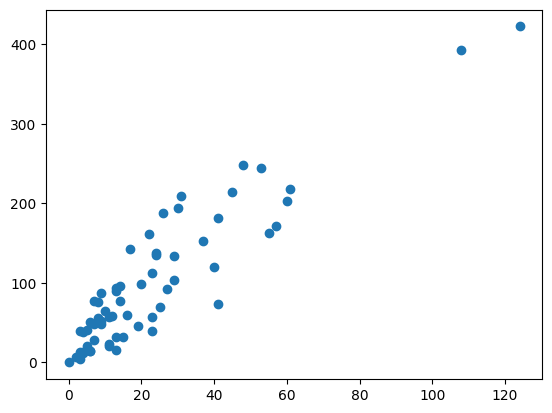

In [2]:
# Load the linear toy dataset (path is relative to this notebook's folder).
df = pd.read_csv('data/linear.csv')
x = df['X'].values
y = df['Y'].values

# Sanity check: scatter plot of raw data (no model yet).
# plot_regression is already implemented in mlrcv/core.py and you do not need to touch it
plot_regression(x, y)

**2.1 Linear regression \[5 pt\]**

---

In this first task, given the loaded data *x* and *y* you should implement the *LinearRegression* class functions in *`mlrcv/regression.py`* to calculate the $\theta_0$ and $\theta$ parameters of the linear function $ f(x) = x^T\theta + \theta_0$ that will fit the data:

- *`calculate_theta`* — fit the parameters from training inputs and targets. *[2 pt]*
- *`predict_y`* — predict $y$ for given $x$ using the fitted parameters. *[1 pt]*

**Besides**, you need to implement *`split_data`* in *`mlrcv/utils.py`* to split your dataset into training and validation sets. (In larger projects you would often also hold out a test set; here we only use train and validation.) *[2 pt]*



In [3]:
from mlrcv.regression import *
from mlrcv.utils import *

# TODO: Implement split_data(...) in mlrcv/utils.py, then run this cell.
# Use a fixed random seed if you use random shuffling, so results are reproducible.
x_train, y_train, x_val, y_val = split_data(x, y)

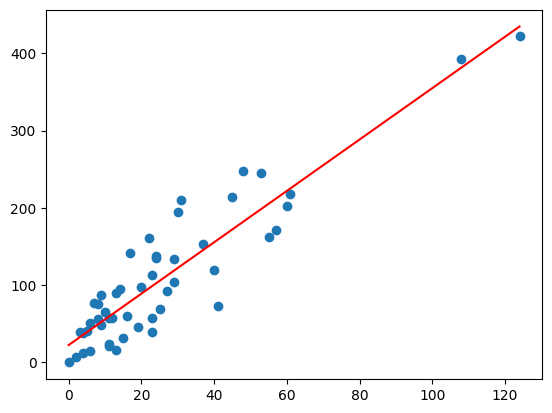

In [4]:
# TODO: Implement LinearRegression.calculate_theta and predict_y in mlrcv/regression.py.
# Fit on the training set using least square
model = LinearRegression()
model.calculate_theta(x_train, y_train)
y_pred = model.predict_y(x_train)

# here we plot predictions on x_train to visualize the fitted line
plot_regression(x_train, y_train, y_pred)

If your implementation have worked, you should see in the plot a red line passing right on the middle of your data, that line is your regression model, which predict a *y* given an input *x*.


**2.2 Non-linear regression \[3 pt\]**

---

In some cases your data may not have a linear relation, which means that linear regression may not correctly fit your data. In this second task you should deal with non-linear regression.

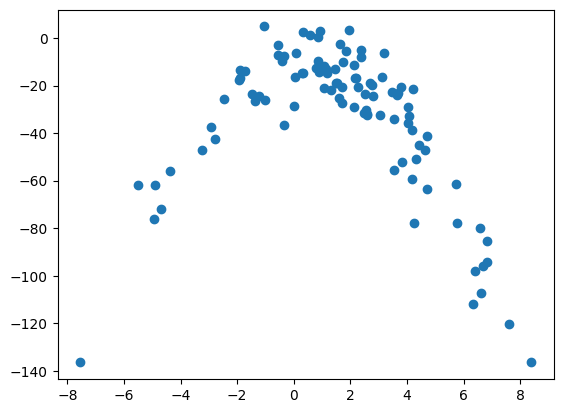

In [5]:
# Load the non-linear toy dataset (same columns as linear.csv).
df = pd.read_csv('data/non_linear.csv')
x = df['X'].values
y = df['Y'].values

plot_regression(x, y)

If you run the same implementations from the last task, you should see that the regression model can not properly fit non-linear data.

In [6]:
x_train, y_train, x_val, y_val = split_data(x, y)

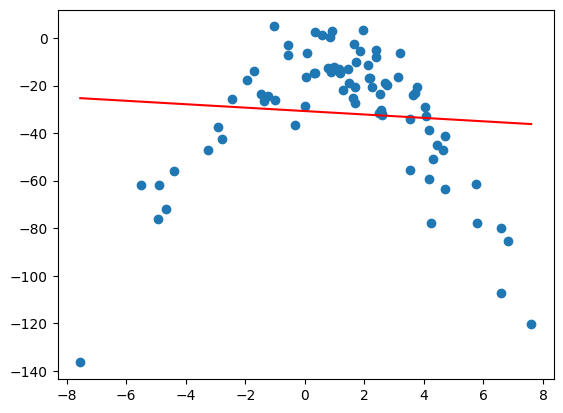

In [7]:
model = LinearRegression()
model.calculate_theta(x_train, y_train)
y_pred = model.predict_y(x_train)
plot_regression(x_train, y_train, y_pred)

For that, a non-linear regression should be implemented in order to fit non-linear data. In the next task you should implement the functions from the *NonLinearRegression* class to calculate the $\theta$ parameters (now it will be a vector of parameters) of the regression function $f(x) = \phi(x)^T\theta$ for non-linear data, where $\phi$ is a non-linear transformation, e.g. polynomial transformation. Your implementation should be able to build a model for *n-degree* polynoms, where the polynom degree will be passed as argument.

Please implement the following functions for the *NonLinearRegression* class:
- *`calculate_theta`* — fit the parameters from training inputs and targets. *[2 pt]*
- *`predict_y`* — predict $y$ for given $x$ using the fitted parameters. *[1 pt]*

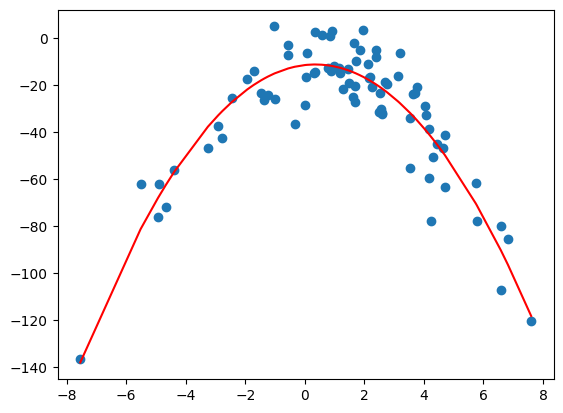

In [8]:
from mlrcv.regression import *

# TODO: Implement NonLinearRegression in mlrcv/regression.py (polynomial features + least squares).
model = NonLinearRegression()
model.calculate_theta(x_train, y_train, degree=2)
y_pred = model.predict_y(x_train)

# Start with degree=2; you should see a parabola-like fit if implemented correctly.
plot_regression(x_train, y_train, y_pred)

If you have implemented it correctly you should se a curved line passing over your data. The non-linear regression fits better our non-linear data since now our model is a polynom and not just a line anymore.

**2.3 Evaluating your model \[2 pt\]**

---

With a non-linear regression model you can increase your polynom degree to improve even more your model. In this task you should implement the root mean square error (RMSE) metric in *mlrcv/utils.py* and evaluate your model with different polynomial degrees (where $\overline{y}$ is the prediction from your model):


$ RMSE(y, \overline{y}) = \sqrt{\frac{1}{N}\sum_{n=1}^{N} (y_n - \overline{y_n})^2} $

**Tip:** The name reads *root–mean–square*, but you *evaluate* it in reverse: square the residuals, take their mean, then take the square root.


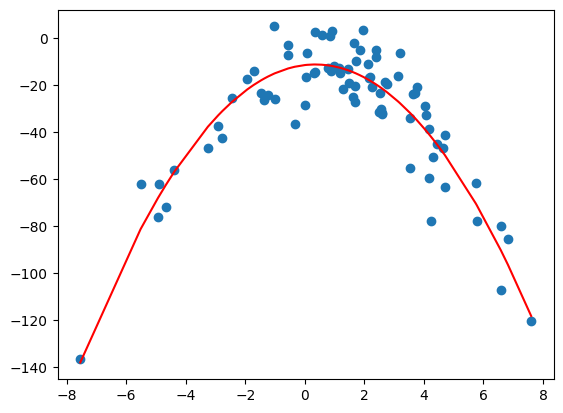

Degree: 2	RMSE train: 10.935490	RMSE val: 10.305709


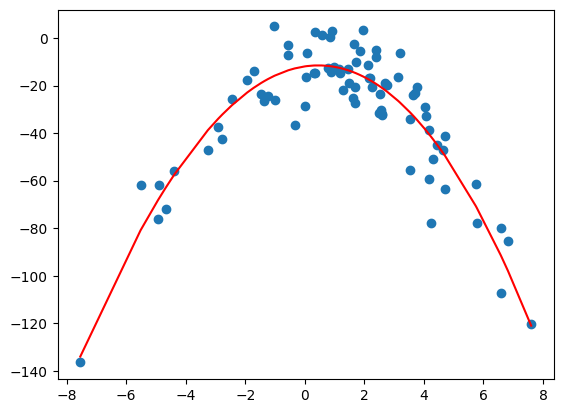

Degree: 3	RMSE train: 10.907155	RMSE val: 10.429319


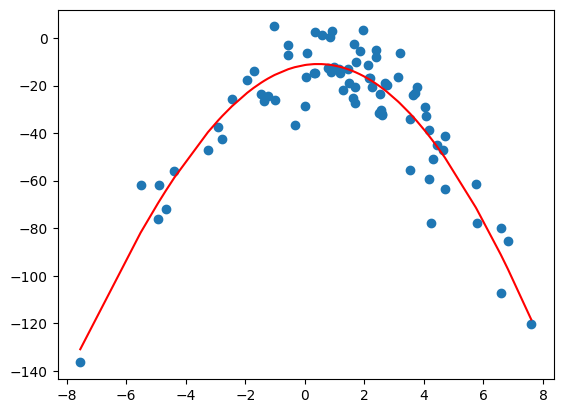

Degree: 4	RMSE train: 10.883011	RMSE val: 10.267145


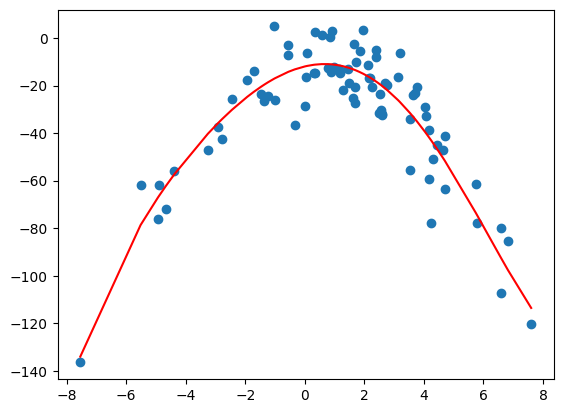

Degree: 5	RMSE train: 10.808120	RMSE val: 10.507626


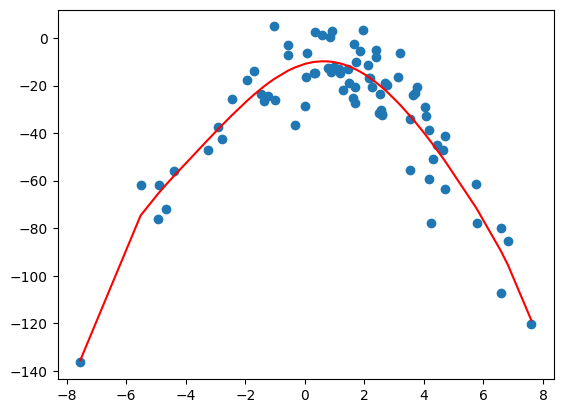

Degree: 6	RMSE train: 10.722087	RMSE val: 11.510260


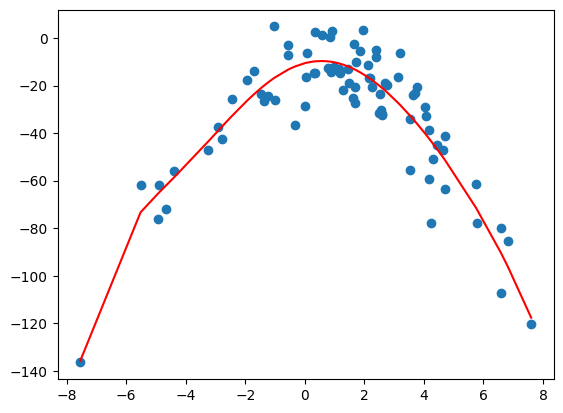

Degree: 7	RMSE train: 10.715551	RMSE val: 10.890403


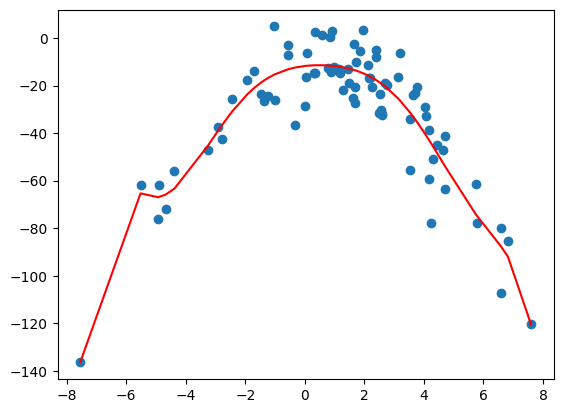

Degree: 8	RMSE train: 10.539731	RMSE val: 20.733106


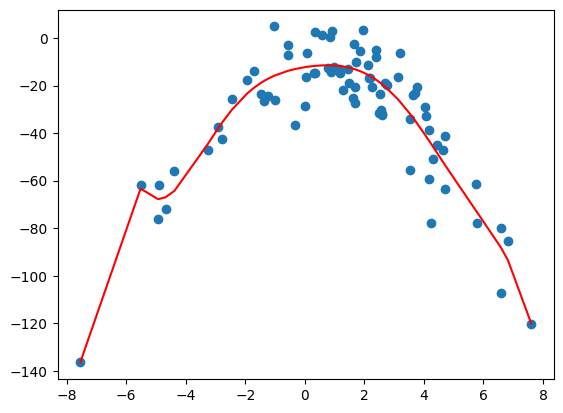

Degree: 9	RMSE train: 10.523550	RMSE val: 13.792013


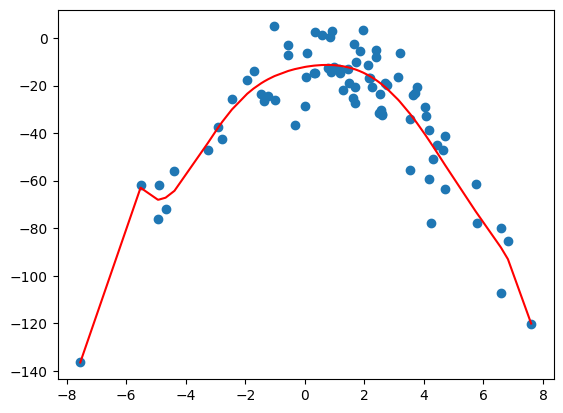

Degree: 10	RMSE train: 10.522212	RMSE val: 17.196253


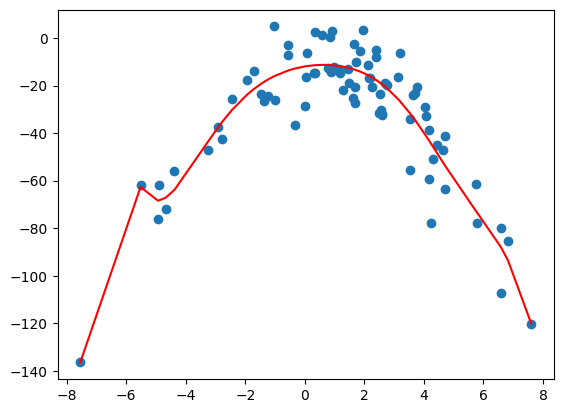

Degree: 11	RMSE train: 10.520499	RMSE val: 11.153113


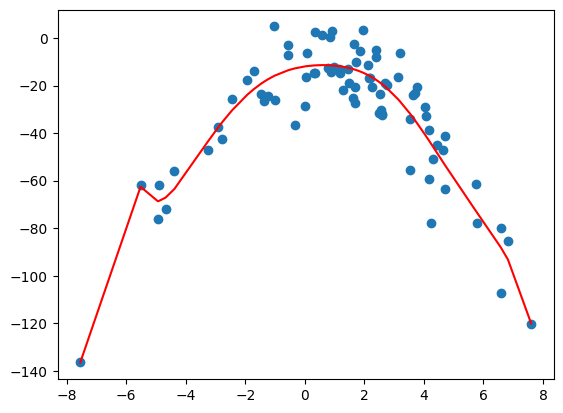

Degree: 12	RMSE train: 10.519894	RMSE val: 19.893030


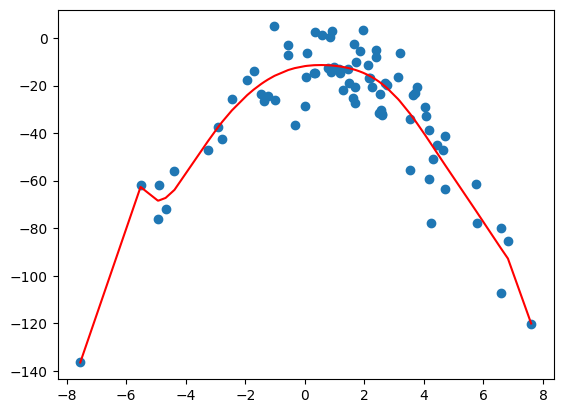

Degree: 13	RMSE train: 10.519177	RMSE val: 51.406085


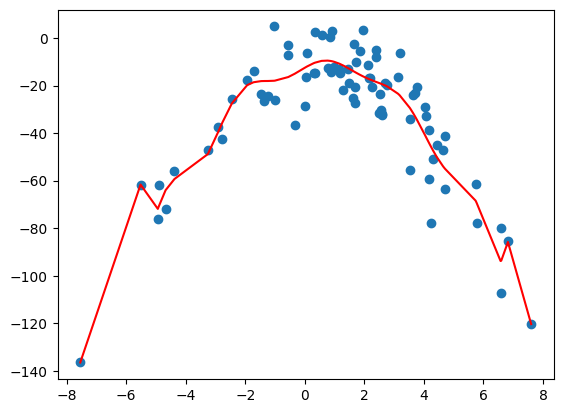

Degree: 14	RMSE train: 10.288957	RMSE val: 1126.935838


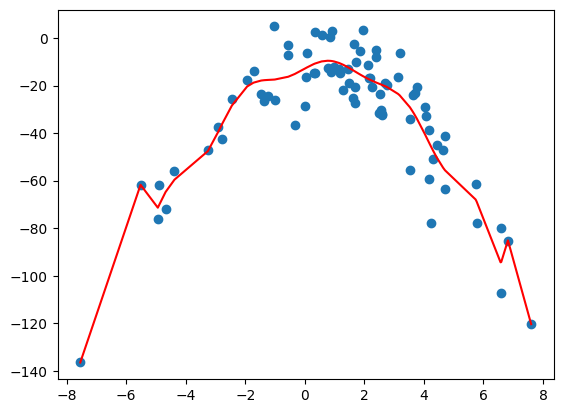

Degree: 15	RMSE train: 10.282237	RMSE val: 1435.359181


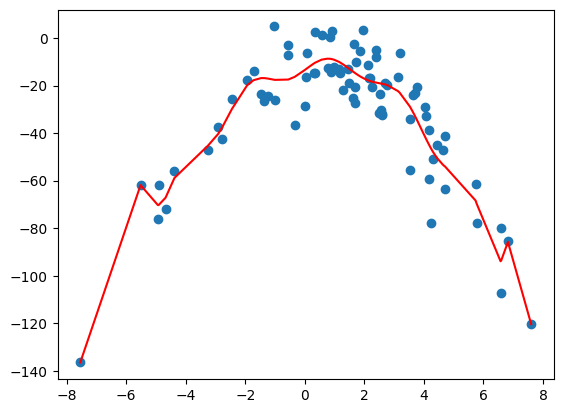

Degree: 16	RMSE train: 10.249761	RMSE val: 255.041969


In [9]:
from mlrcv.regression import *

##################################################################################
# call here your functions. You should:
# - calculate the function parameters theta (vector of thetas)
# - infer the y_val_pred values given x_val and the calculated theta with degree=d
# - calculate the RMSE for both the training and validation sets
##################################################################################

for d in range(2,17):
    model = NonLinearRegression()
    model.calculate_theta(x_train, y_train, degree=d)
    y_pred = model.predict_y(x_train)

    plot_regression(x_train, y_train, y_pred)
    y_val_pred = model.predict_y(x_val)

    # TODO: implement rmse in mlrcv/utils.py, for calculating the rmse metric
    train_rmse = rmse(y_train, y_pred)
    val_rmse = rmse(y_val, y_val_pred)
    # print root mean square error for train and validation sets
    print('Degree: %d\tRMSE train: %f\tRMSE val: %f' % (d, train_rmse, val_rmse))

In the plots above, as the polynomial degree increases, training RMSE tends to decrease, while validation RMSE eventually increases. Why does this happen?

- *Answer:*

This is the phenomenon of overfitting. As the polynomial degree increases, the model becomes more complex and even begins to learn the noise in the training data. Therefore:

Training RMSE decreases, the model fits the training data perfectly.
Validation RMSE increases, the model loses its generalization ability because it memorizes the noise and performs poorly on new data.

This is an illustration of the bias-variance tradeoff: a low-degree polynomial has high bias/low variance (underfitting), a high-degree polynomial has low bias/high variance (overfitting).



*Bonus — not graded, but the idea is important and may come up on the final exam.*

**Assignment Submission**

---


To submit your assignment, run the following command from the root of the repository (For Linux and MacOS):

```bash
sh submit.sh
```

For Windows, please use `submit.bat`.

**Check That You Actually Submitted**

You can check that your submission worked in several ways:

1. There is a new line in the file submission.txt with current date and time.
2. There is a new commit in your git history with the title "Submission".